In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from scipy.integrate import simpson
from scipy.signal import find_peaks
from scipy.special import loggamma, erfc
from BayesianSignal import *



In [2]:
omega_true = 10
time_total = 4
t, signal = make_dummy_signal(time_total=time_total, n_timesteps=10000, omega=omega_true, noise_ratio=0.1, signal_type="sin")
uncerts = np.ones_like(signal) * 0.1

omega_min = 2
omega_max = 20
max_spacing = 1/(2*np.pi * time_total) #* Largest space between omega values to ensure no peaks are missed
num_omega = 1000#math.ceil((omega_max - omega_min) / max_spacing)
# print(f"Sampling {num_omega} omega values between {omega_min} and {omega_max}")
Omega = np.linspace(omega_min, omega_max, num_omega)

Phi = np.linspace(0, 2*np.pi, 2)

M = np.arange(2, 13)

starttime = time.perf_counter()
log_P_D = calculate_logprob(t, signal, uncerts, Omega, Phi, M, r_min=0, r_max=1)
slow_duration = time.perf_counter() - starttime

starttime = time.perf_counter()
log_P_D_fast = calculate_logprob_fast(t, signal, uncerts, Omega, Phi, M, r_min=0, r_max=1)
fast_duration = time.perf_counter() - starttime

print(f"Slow duration: {slow_duration:.2f} s")
print(f"Fast duration: {fast_duration:.2f} s")

P_w, log_offset = marginalize_Phi_M(log_P_D, Omega, Phi, M, omega_min, omega_max)
# plt.plot(Omega, P_D_marginalized)
# plt.show()

100% |########################################################################|


PARALELL EXECUTION: Using n_jobs = 8 with chunk_size = 32


Slow duration: 4.96 s
Fast duration: 1.91 s


In [3]:
np.sum(np.abs(log_P_D - log_P_D_fast))

np.float64(0.0)

In [4]:
log_odds_ratio(log_P_D, log_P_constant(t, signal, uncerts, A_min=0, A_max=1), Omega, Phi, M, omega_min, omega_max)

np.float64(24565.3401875285)

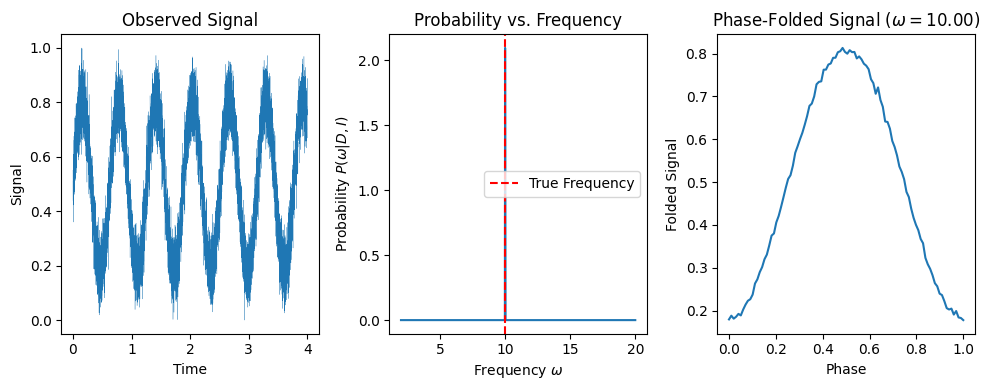

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))

omega_best = best_omega(Omega, P_w)
num_bins_display = 100
folded_signal, bin_phases = phase_fold(t, signal, omega=omega_best, phi=np.pi/2, num_bins=num_bins_display, reduction='mean')

# First subplot: the signal versus time
axs[0].plot(t, signal, lw=0.2)
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Signal')
axs[0].set_title('Observed Signal')

# Second subplot: Omega vs. Pw (current plot)
axs[1].plot(Omega, P_w)
axs[1].axvline(x=omega_true, color='r', linestyle='--', label='True Frequency')
# axs[1].axvline(x=omega_best, color='g', linestyle='--', label='Best Fit Frequency')
axs[1].set_xlabel(r'Frequency $\omega$')
axs[1].set_ylabel(r"Probability $P(\omega | D, I)$")
axs[1].legend()
axs[1].set_title('Probability vs. Frequency')
axs[1].ticklabel_format(axis='y', style='sci')

# Third subplot: Phase-folded signal using best-fit frequency
axs[2].plot(bin_phases, folded_signal)
axs[2].set_xlabel('Phase')
axs[2].set_ylabel('Folded Signal')
axs[2].set_title(rf'Phase-Folded Signal ($\omega={omega_best:.2f}$)')

plt.tight_layout()
plt.show()